 STITCHING WALK-FORWARD OUT-OF-SAMPLE FOLDS 
Found 13 CSV files. Parsing and standardizing headers...

✅ Successfully stitched 13 out-of-sample segments.
✅ Total Realized Out-of-Sample Trades: 285

       SYSTEMATIC ALPHA TEARSHEET (OOS)       
Total Stitched PnL:        $3,415.00
Profit Factor:             1.19
Win Rate:                  28.07%
Expectancy (Avg Trade):    $11.98
Max Peak-to-Trough DD:     $-2,800.70
Estimated Sharpe Ratio:    1.55
Trade Sample Size:         285 executions


/tmp/ipykernel_1034/2853154723.py:65: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  temp_df['Date'] = pd.to_datetime(temp_df[matched_date_col], errors='coerce')
/tmp/ipykernel_1034/2853154723.py:65: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  temp_df['Date'] = pd.to_datetime(temp_df[matched_date_col], errors='coerce')
/tmp/ipykernel_1034/2853154723.py:65: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  temp_df['Date'] = pd.to_datetime(temp_df[matched_date_col], errors='coerce')
/tmp/ipykernel_1034/2853154723.py:65: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specifie

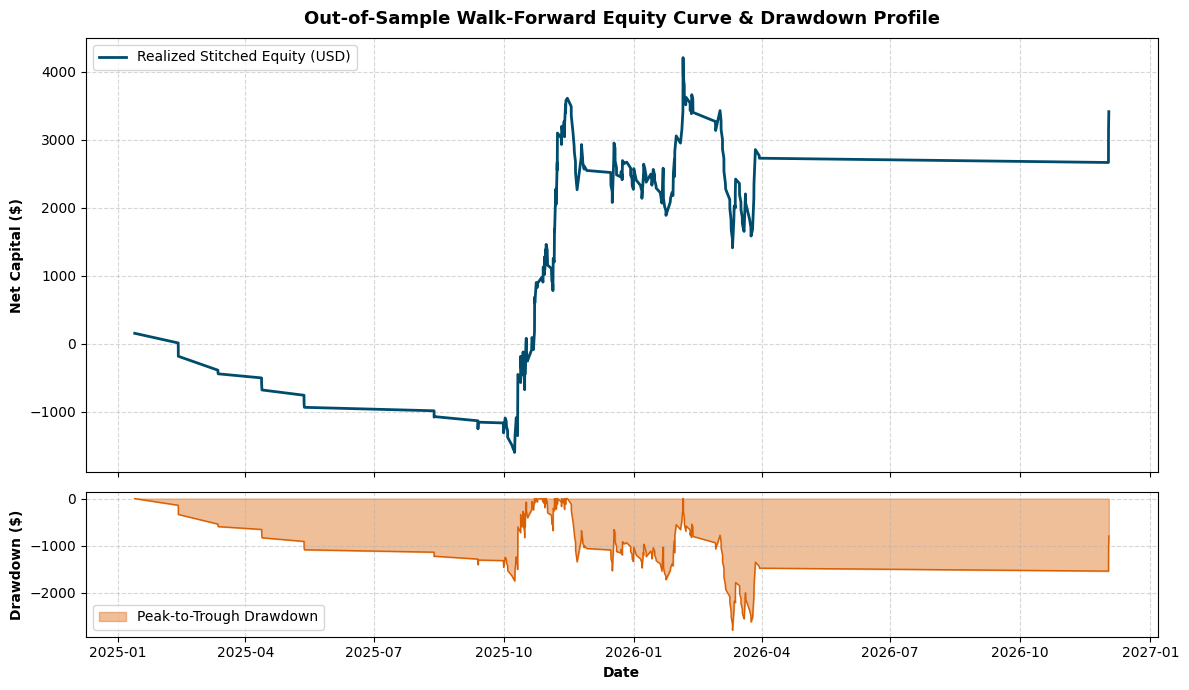

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("=" * 50)
print(" STITCHING WALK-FORWARD OUT-OF-SAMPLE FOLDS ")
print("=" * 50)

# 1. Locate all CSV files in the workspace
csv_files = glob.glob("*.csv")

if not csv_files:
    # Check /content directory explicitly for Colab environments
    csv_files = glob.glob("/content/*.csv")

if not csv_files:
    raise FileNotFoundError(
        "No CSV files found. Confirm all 13 CSV files are uploaded directly inside the '/content' folder."
    )

print(f"Found {len(csv_files)} CSV files. Parsing and standardizing headers...\n")

def clean_currency_series(series):
    """Converts NinjaTrader currency strings ($125.50, ($45.00), -50) to clean floats."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)

    cleaned = (
        series.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('(', '-', regex=False)
        .str.replace(')', '', regex=False)
        .str.strip()
    )
    return pd.to_numeric(cleaned, errors='coerce').fillna(0.0)

processed_dfs = []

for file in csv_files:
    try:
        temp_df = pd.read_csv(file)
    except Exception as e:
        print(f"Skipping unreadable file {file}: {e}")
        continue

    # Clean whitespace from column headers
    temp_df.columns = [c.strip() for c in temp_df.columns]

    # Map the Date/Time column (Exit time preferred for realized PnL)
    date_candidates = ['Exit time', 'Exit Time', 'Entry time', 'Entry Time', 'Date', 'Time', 'Timestamp']
    matched_date_col = next((col for col in date_candidates if col in temp_df.columns), None)

    # Map the Profit/Loss column
    pnl_candidates = ['Profit', 'Net profit', 'Net Profit', 'Profit ($)', 'Net_PnL', 'PnL', 'Cum. profit']
    matched_pnl_col = next((col for col in pnl_candidates if col in temp_df.columns), None)

    if matched_date_col is None or matched_pnl_col is None:
        print(f"⚠️ Warning: File '{os.path.basename(file)}' does not match NT8 trade format. Skipped.")
        continue

    # Standardize schema
    temp_df['Date'] = pd.to_datetime(temp_df[matched_date_col], errors='coerce')
    temp_df['Net_PnL'] = clean_currency_series(temp_df[matched_pnl_col])

    # Keep only valid trades
    temp_df = temp_df.dropna(subset=['Date'])
    processed_dfs.append(temp_df[['Date', 'Net_PnL']])

if not processed_dfs:
    raise ValueError("None of the uploaded files contained valid NinjaTrader trade columns.")

# 2. Concatenate and Chronologically Order
df = pd.concat(processed_dfs, ignore_index=True)
df = df.sort_values('Date').reset_index(drop=True)

print(f"✅ Successfully stitched {len(processed_dfs)} out-of-sample segments.")
print(f"✅ Total Realized Out-of-Sample Trades: {len(df)}\n")

# 3. Compute Cumulative Equity & Continuous Drawdown
df['Cumulative_Equity'] = df['Net_PnL'].cumsum()
df['Peak'] = df['Cumulative_Equity'].cummax()
df['Drawdown'] = df['Cumulative_Equity'] - df['Peak']
max_drawdown = df['Drawdown'].min()

# 4. Compute Core Performance Analytics
total_profit = df['Net_PnL'].sum()
winning_trades = df[df['Net_PnL'] > 0]['Net_PnL']
losing_trades = df[df['Net_PnL'] < 0]['Net_PnL']

num_trades = len(df)
win_rate = (len(winning_trades) / num_trades) * 100 if num_trades > 0 else 0.0
gross_profit = winning_trades.sum()
gross_loss = abs(losing_trades.sum())

profit_factor = (gross_profit / gross_loss) if gross_loss != 0 else np.inf
average_trade = df['Net_PnL'].mean() if num_trades > 0 else 0.0

# Annualized Sharpe Ratio (Daily PnL aggregation)
daily_returns = df.groupby(df['Date'].dt.date)['Net_PnL'].sum()
if len(daily_returns) > 1 and daily_returns.std() != 0:
    sharpe_ratio = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
else:
    sharpe_ratio = 0.0

# 5. Output Institutional Tearsheet Summary
print("=" * 50)
print("       SYSTEMATIC ALPHA TEARSHEET (OOS)       ")
print("=" * 50)
print(f"Total Stitched PnL:        ${total_profit:,.2f}")
print(f"Profit Factor:             {profit_factor:.2f}")
print(f"Win Rate:                  {win_rate:.2f}%")
print(f"Expectancy (Avg Trade):    ${average_trade:,.2f}")
print(f"Max Peak-to-Trough DD:     ${max_drawdown:,.2f}")
print(f"Estimated Sharpe Ratio:    {sharpe_ratio:.2f}")
print(f"Trade Sample Size:         {num_trades} executions")
print("=" * 50)

# 6. Generate Clean Institutional Chart
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1.plot(df['Date'], df['Cumulative_Equity'], label='Realized Stitched Equity (USD)', color='#004c6d', linewidth=2)
ax1.set_title('Out-of-Sample Walk-Forward Equity Curve & Drawdown Profile', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Net Capital ($)', fontsize=10, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

# Underwater Drawdown Profile
ax2.fill_between(df['Date'], df['Drawdown'], 0, color='#d95f02', alpha=0.4, label='Peak-to-Trough Drawdown')
ax2.plot(df['Date'], df['Drawdown'], color='#d95f02', linewidth=1)
ax2.set_ylabel('Drawdown ($)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Date', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='lower left')

plt.tight_layout()
plt.show()